# Train and Register the Model

In this notebook, you will build a lightweight baseline model for taxi trip duration, inspect what the engineered features look like, and register the finished pipeline in MLflow.

Before you run the notebook, complete [01-setup-local-stack.md](01-setup-local-stack.md) and keep the local MLflow, Prefect, and Postgres services running.

The goal is not to build the most accurate model possible, but to create a clear, repeatable baseline that can be reused by the batch and online prediction lessons.


## Workflow

```mermaid
flowchart LR
    A["Load taxi<br>Parquet data"] --> B["Prepare route and<br>distance features"]
    B --> C["Train regression<br>pipeline"]
    C --> D["Compare against a<br>simple baseline"]
    D --> E["Log run and model<br>to MLflow"]
```


In [1]:
import mlflow
import pandas as pd
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

from src.common.config import get_settings
from src.common.features import (
    TARGET_COLUMN,
    load_dataframe,
    prepare_dataframe,
    to_model_records,
)
from src.common.model_registry import configure_tracking, ensure_experiment

settings = get_settings()
settings

ProjectSettings(mlflow_tracking_uri='http://127.0.0.1:5001', prefect_api_url='http://127.0.0.1:4200/api', experiment_name='green-taxi-duration', registered_model_name='green-taxi-duration', model_uri=None, model_alias=None, model_stage=None, model_version=None, run_id=None, model_artifact_path='model', train_data_uri='https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet', batch_input_uri='https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet', batch_output_dir=PosixPath('/Users/youssef/projects/bootcamp/mle-batch-and-stream-predictions/data/predictions'), artifacts_dir=PosixPath('/Users/youssef/projects/bootcamp/mle-batch-and-stream-predictions/storage/mlartifacts'))

## Load and Inspect the Training Data

We start with one Parquet file from the public NYC Green Taxi dataset. The helper function below keeps the notebook aligned with the active project code.

For training, we keep trips lasting 1-60 minutes with distances of 0.1-100 miles (inclusive) to exclude invalid values and outliers.

In [2]:
df_raw = load_dataframe(settings.train_data_uri)
df_raw.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2025-01-01 00:03:01,2025-01-01 00:17:12,N,1.0,75,235,1.0,5.93,24.70,...,0.5,6.80,0.00,NaN,1.0,34.00,1.0,1.0,0.00,0.0
1,2,2025-01-01 00:19:59,2025-01-01 00:25:52,N,1.0,166,75,1.0,1.32,8.60,...,0.5,0.00,0.00,NaN,1.0,11.10,2.0,1.0,0.00,0.0
2,2,2025-01-01 00:05:29,2025-01-01 00:07:21,N,5.0,171,73,1.0,0.41,25.55,...,0.0,0.00,0.00,NaN,1.0,26.55,2.0,2.0,0.00,0.0
3,2,2025-01-01 00:52:24,2025-01-01 01:07:52,N,1.0,74,223,1.0,4.12,21.20,...,0.5,6.13,6.94,NaN,1.0,36.77,1.0,1.0,0.00,0.0
4,2,2025-01-01 00:25:05,2025-01-01 01:01:10,N,1.0,66,158,1.0,4.71,33.80,...,0.5,7.81,0.00,NaN,1.0,46.86,1.0,1.0,2.75,0.0


In [3]:
prepared = prepare_dataframe(df_raw, include_target=True)
print(f"Rows before/after filtering: {len(df_raw):,} / {len(prepared):,}")
prepared[["trip_route", "trip_distance", TARGET_COLUMN]].head()

Rows before/after filtering: 48,326 / 44,525


,trip_route,trip_distance,trip_duration_minutes
0,75_235,5.93,14.183333
1,166_75,1.32,5.883333
2,171_73,0.41,1.866667
3,74_223,4.12,15.466667
4,66_158,4.71,36.083333


The model sees only two inputs:

- `trip_route`, a combined categorical feature built from pickup and dropoff IDs;
- `trip_distance`, a numeric distance feature.

That makes the baseline easy to understand and easy to reuse later.

In [4]:
records = to_model_records(prepared)
target = prepared[TARGET_COLUMN]

X_train, X_valid, y_train, y_valid = train_test_split(
    records,
    target,
    test_size=0.2,
    random_state=42,
)

len(X_train), len(X_valid)

(35620, 8905)

## Train the Baseline Pipeline

The pipeline combines `DictVectorizer` with `LinearRegression`. This is a good baseline because the preprocessing and model are visible in one object.

In [5]:
pipeline = make_pipeline(DictVectorizer(), LinearRegression())
pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_valid)
rmse = root_mean_squared_error(y_valid, predictions)
print(f"RMSE: {rmse:.2f}")

RMSE: 4.80


## Add One Useful Comparison

A printed RMSE is more informative when we compare it against a very simple reference. Here we compare the trained model to a naive predictor that always uses the training set mean duration.

In [6]:
mean_baseline = pd.Series([y_train.mean()] * len(y_valid), index=y_valid.index)
comparison = pd.DataFrame(
    {
        "model": ["mean baseline", "linear regression pipeline"],
        "rmse": [
            root_mean_squared_error(y_valid, mean_baseline),
            rmse,
        ],
    }
)
comparison["improvement_vs_baseline"] = comparison["rmse"].iloc[0] - comparison["rmse"]
comparison

,model,rmse,improvement_vs_baseline
0,mean baseline,8.427723,0.00000
1,linear regression pipeline,4.800434,3.62729


## Visual Check: Residual Pattern

A residual plot helps confirm that the trained pipeline is doing more than just memorizing the average duration. If the points are centered around zero without an obvious trend, the baseline is behaving reasonably for this example.

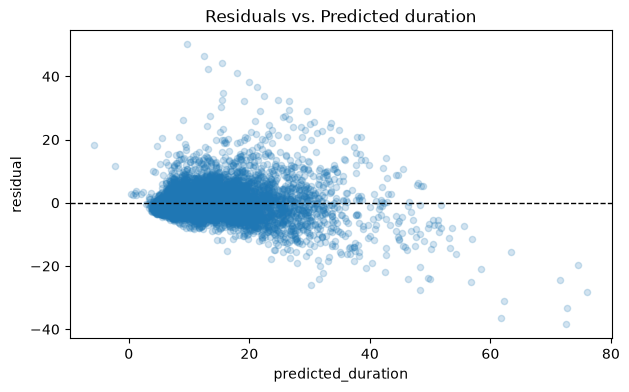

In [7]:
import matplotlib.pyplot as plt

residual_frame = pd.DataFrame(
    {
        "actual_duration": y_valid,
        "predicted_duration": predictions,
    }
)
residual_frame["residual"] = (
    residual_frame["actual_duration"] - residual_frame["predicted_duration"]
)

ax = residual_frame.plot.scatter(
    x="predicted_duration",
    y="residual",
    alpha=0.2,
    figsize=(7, 4),
    title="Residuals vs. Predicted duration",
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
plt.show()

A lower RMSE means the predictions are closer to the observed trip durations. If the linear model beats the mean baseline by a visible margin, it is strong enough for the rest of the repo.

## Register the Model in MLflow

The next cell logs the validation metric and registers the fitted pipeline so the batch flow and API can reuse it without retraining.

In [8]:
configure_tracking(settings.mlflow_tracking_uri)
experiment_id = ensure_experiment(settings.experiment_name)
mlflow.set_experiment(settings.experiment_name)

with mlflow.start_run(experiment_id=experiment_id, run_name="notebook-baseline") as run:
    mlflow.log_param("feature_columns", "trip_route,trip_distance")
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_metric("rmse", float(rmse))
    mlflow.sklearn.log_model(
        sk_model=pipeline,
        name=settings.model_artifact_path,
        registered_model_name=settings.registered_model_name,
        serialization_format="skops",
    )
    run_summary = {
        "run_id": run.info.run_id,
        "experiment_name": settings.experiment_name,
        "registered_model_name": settings.registered_model_name,
        "rmse": float(rmse),
    }

run_summary

Registered model 'green-taxi-duration' already exists. Creating a new version of this model...
2026/09/24 16:14:50 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: green-taxi-duration, version 2
Created version '2' of model 'green-taxi-duration'.


🏃 View run notebook-baseline at: http://127.0.0.1:5001/#/experiments/1/runs/e2770ab76ac343aa8601f0c16bcbfbc0
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


{'run_id': 'e2770ab76ac343aa8601f0c16bcbfbc0',
 'experiment_name': 'green-taxi-duration',
 'registered_model_name': 'green-taxi-duration',
 'rmse': 4.800433953144878}

## Wrap Up

On a fresh stack, running the sanity check in [01-setup-local-stack.md](01-setup-local-stack.md) once and then this notebook once creates **version 1** and **version 2** of `green-taxi-duration`. Each rerun registers another version. With the default settings, the batch flow and a newly started API use the latest version.